# ___ Modeling Draft 2 ___

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import cross_val_score, StratifiedKFold, learning_curve
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

---
##  Chargement des données

In [30]:
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

print(f'X_train : {X_train.shape} | X_test : {X_test.shape}')

X_train : (1600, 20) | X_test : (400, 20)


---
## Vérification Data Leakage (Corrélation forte avec la cible)

Top 10 features les plus corrélées avec PCOS (Y/N):
Follicle No. (R)        0.634947
Follicle No. (L)        0.601352
Skin darkening (Y/N)    0.473487
hair growth(Y/N)        0.473095
Weight gain(Y/N)        0.422705
Cycle(R/I)              0.401711
Fast food (Y/N)         0.396518
AMH(ng/mL)              0.310715
Pimples(Y/N)            0.269956
BMI                     0.199799
dtype: float64


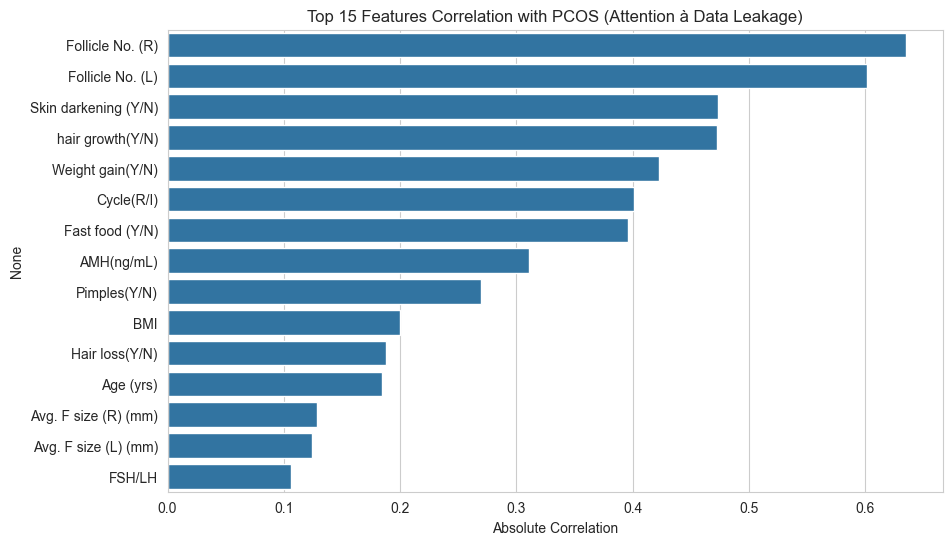

In [31]:
corr_with_target = X_train.corrwith(y_train).abs().sort_values(ascending=False)
print("Top 10 features les plus corrélées avec PCOS (Y/N):")
print(corr_with_target.head(10))

plt.figure(figsize=(10, 6))
sns.barplot(x=corr_with_target.head(15).values, y=corr_with_target.head(15).index)
plt.title('Top 15 Features Correlation with PCOS (Attention à Data Leakage)')
plt.xlabel('Absolute Correlation')
plt.show()

---
##  Fonction d'évaluation améliorée

In [32]:
results = []

def evaluate_model(model, name, show_learning_curve=False):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob) if y_prob is not None else np.nan

    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    cv_f1 = cross_val_score(model, X_train, y_train, cv=cv, scoring='f1')

    results.append({
        'Model': name,
        'Accuracy': round(acc, 4),
        'F1-Score': round(f1, 4),
        'ROC-AUC': round(auc, 4),
        'CV_F1_mean': round(cv_f1.mean(), 4),
        'CV_F1_std': round(cv_f1.std(), 4),
        'Train_Test_Gap': round(abs(cv_f1.mean() - f1), 4)
    })

    print(f'{name:25} = F1: {f1:.4f} | AUC: {auc:.4f} | CV_F1: {cv_f1.mean():.4f} ± {cv_f1.std():.4f} | Gap: {abs(cv_f1.mean() - f1):.4f}')

    if show_learning_curve:
        train_sizes, train_scores, val_scores = learning_curve(model, X_train, y_train, cv=5, scoring='f1', n_jobs=-1)
        plt.plot(train_sizes, train_scores.mean(axis=1), label='Train')
        plt.plot(train_sizes, val_scores.mean(axis=1), label='Validation')
        plt.title(f'Learning Curve - {name}')
        plt.xlabel('Training Size')
        plt.ylabel('F1 Score')
        plt.legend()
        plt.show()

---
## Test des Modèles

Logistic Regression       = F1: 0.8745 | AUC: 0.9621 | CV_F1: 0.8293 ± 0.0311 | Gap: 0.0452


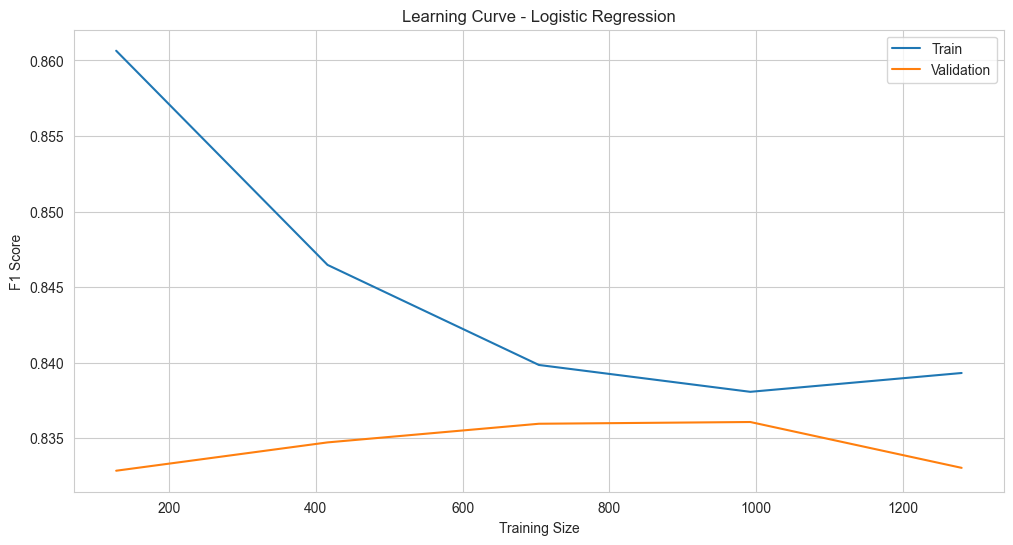

Random Forest             = F1: 0.9918 | AUC: 0.9999 | CV_F1: 0.9887 ± 0.0070 | Gap: 0.0031


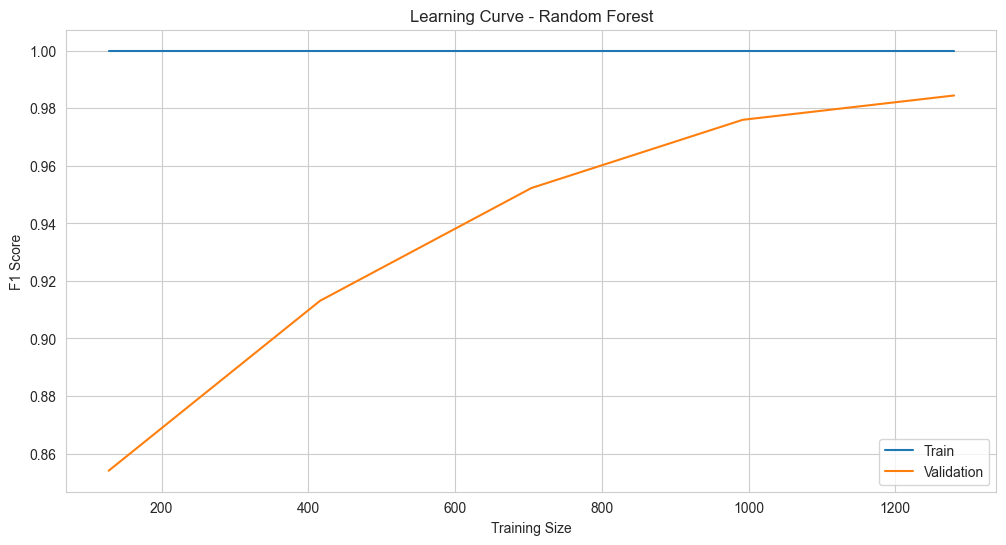

XGBoost                   = F1: 0.9878 | AUC: 0.9999 | CV_F1: 0.9907 ± 0.0072 | Gap: 0.0029


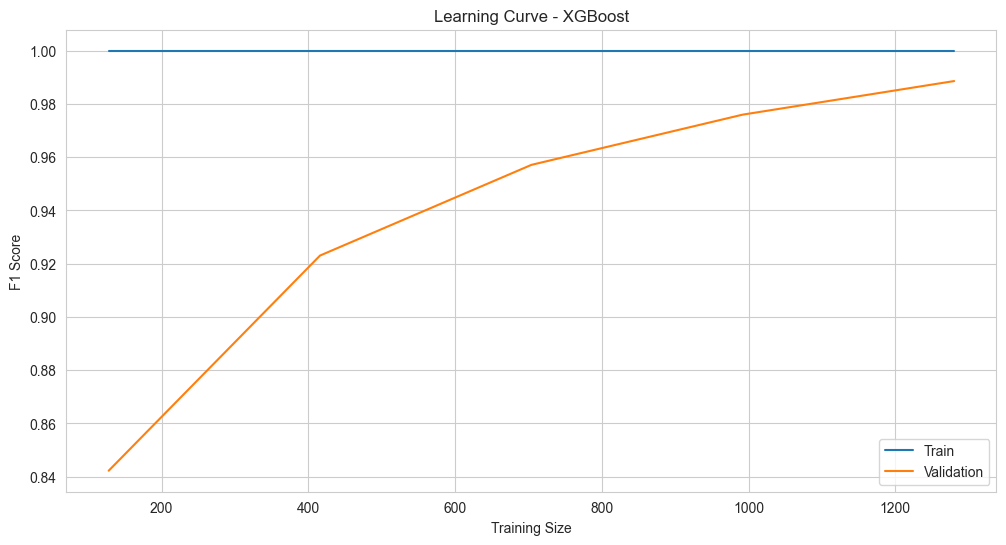

LightGBM                  = F1: 0.9959 | AUC: 1.0000 | CV_F1: 0.9876 ± 0.0089 | Gap: 0.0083


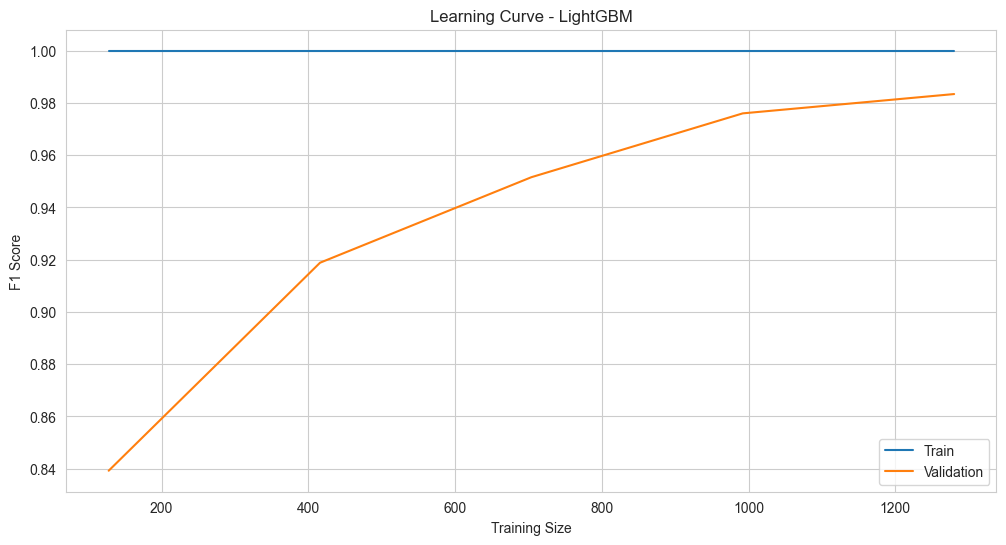

SVM RBF                   = F1: 0.9712 | AUC: 0.9984 | CV_F1: 0.9511 ± 0.0233 | Gap: 0.0201


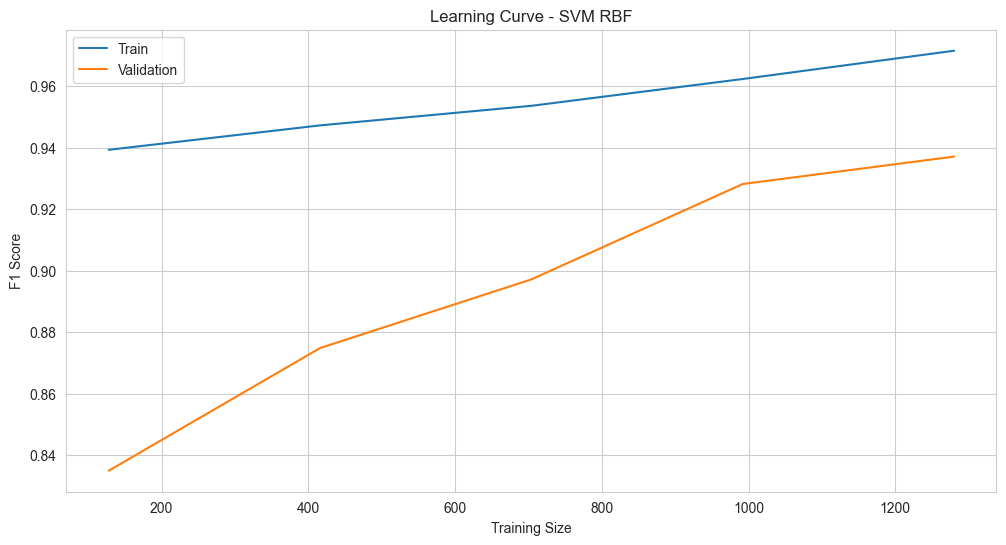

KNN                       = F1: 0.9000 | AUC: 0.9815 | CV_F1: 0.8766 ± 0.0320 | Gap: 0.0234


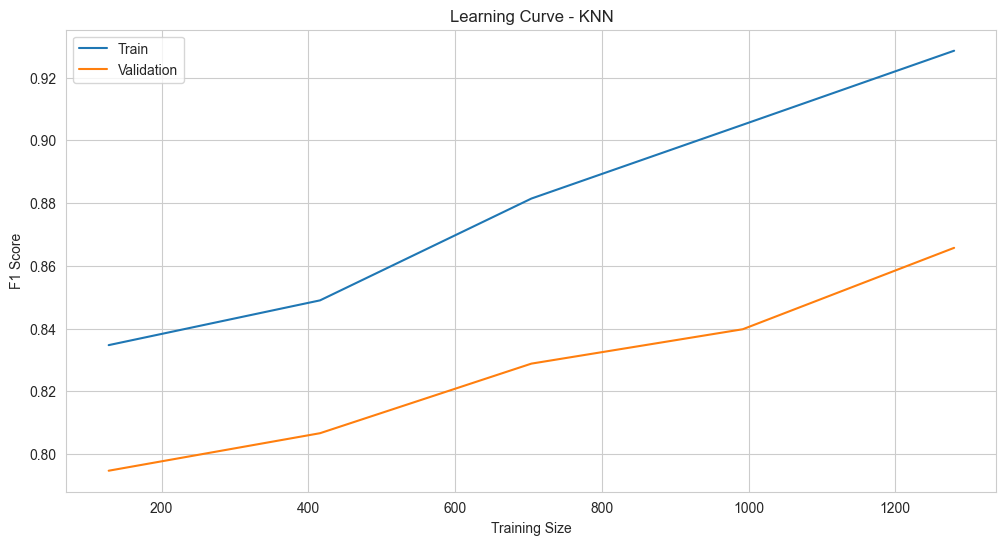

In [33]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=5, random_state=42, eval_metric='logloss'),
    "LightGBM": LGBMClassifier(n_estimators=300, learning_rate=0.1, max_depth=5, random_state=42, verbose=-1),
    "SVM RBF": SVC(probability=True, kernel='rbf', random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

for name, clf in models.items():
    pipeline = Pipeline([('scaler', StandardScaler()), ('clf', clf)])
    evaluate_model(pipeline, name, show_learning_curve=(name in ['Logistic Regression','XGBoost', 'Random Forest','LightGBM','SVM RBF','KNN']))


## 5. Tableau Comparatif Final

In [34]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='F1-Score', ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,F1-Score,ROC-AUC,CV_F1_mean,CV_F1_std,Train_Test_Gap
0,LightGBM,0.9975,0.9959,1.0000,0.9876,0.0089,0.0083
1,Random Forest,0.9950,0.9918,0.9999,0.9887,0.0070,0.0031
2,XGBoost,0.9925,0.9878,0.9999,0.9907,0.0072,0.0029
3,SVM RBF,0.9825,0.9712,0.9984,0.9511,0.0233,0.0201
4,KNN,0.9400,0.9000,0.9815,0.8766,0.0320,0.0234
5,Logistic Regression,0.9275,0.8745,0.9621,0.8293,0.0311,0.0452


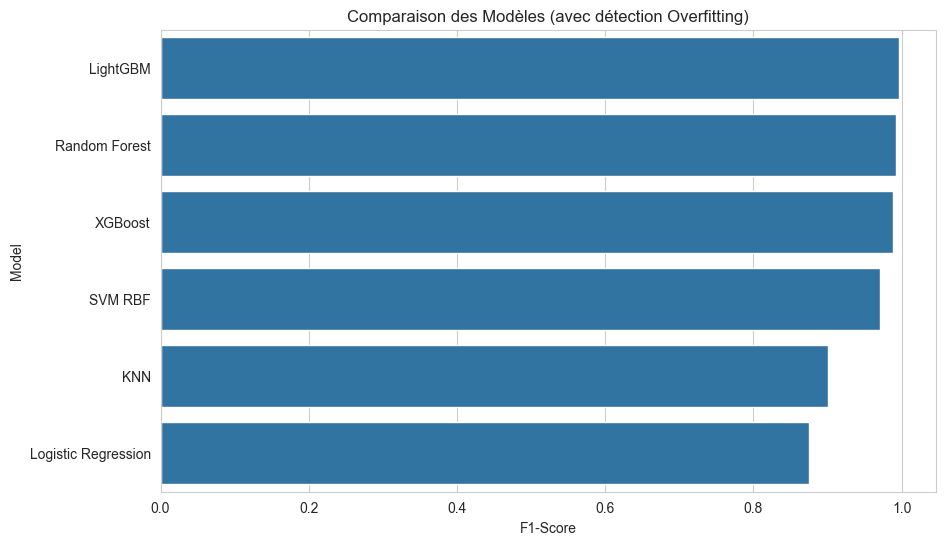

In [35]:
plt.figure(figsize=(10,6))
sns.barplot(data=results_df, x='F1-Score', y='Model')
plt.title('Comparaison des Modèles (avec détection Overfitting)')
plt.show()